<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-6 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> RNN for Time Series </h2> </html>


RNNs are used for sequence modelling. This tutorial will look at time series data to be modelled and predicted using RNNs.

In [ ]:
# Import Libraries (pandas, numpy, matplotlib)

# ....
# ...
# ...


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data

We will use retail data for time-series modeling.

Link to the dataset:
 https://fred.stlouisfed.org/series/MRTSSM448USN

Information about the Advance Monthly Retail Sales Survey can be found on the Census website at:
https://www.census.gov/retail/marts/about_the_surveys.html

Release: Advance Monthly Sales for Retail and Food Services  
Units:  Millions of Dollars, Not Seasonally Adjusted
Frequency:  Monthly

Suggested Citation:
U.S. Census Bureau, Advance Retail Sales: Clothing and Clothing Accessory Stores [RSCCASN], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RSCCASN, January 25, 2025.



##### Read data first -  Use index_col = 'DATE' and 'parse_dates = True' as a parameter.

_________________![image.png](attachment:d2f728cb-4c14-4ede-9ca4-3210197b3bf5.png)

In [3]:
df = pd.read_csv('MRTSSM448USN_24-1.csv', index_col='observation_date', parse_dates=True)

In [ ]:
#pd.read_csv

In [ ]:
# Print the first few rows of data
#d
# ...

In [4]:
df.head()

,MRTSSM448USN
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


_______________![image.png](attachment:7e472928-25f6-4701-891d-d6e138d8301c.png)

In [5]:
df.tail()

,MRTSSM448USN
observation_date,
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318
2024-11-01,29762
2024-12-01,41199


Does the sales column has any name?

If no, set the name of the colum as 'Sales'.

In [ ]:
# Set name of column as 'Sales'. Use - df.columns

# ...


In [6]:
df.columns = ['Sales']
df.head()

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


Plot your data - Year vs Sales

hint: use df.plot  and plt.show()

____________![image.png](attachment:805024e0-d954-465a-b7e2-ddfb909885ff.png)

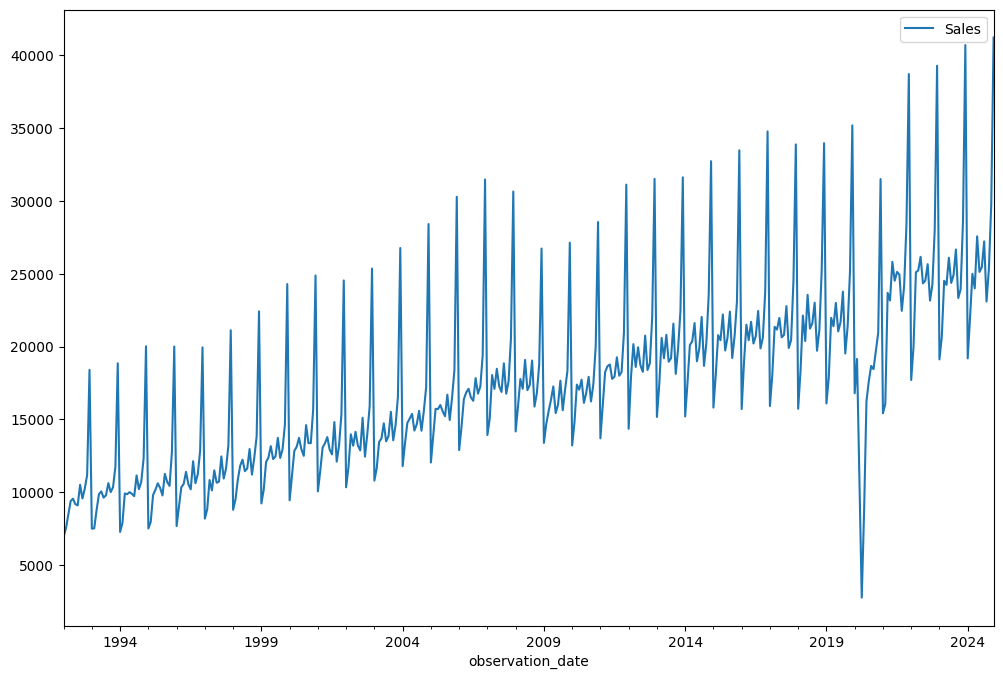

In [7]:
df.plot(figsize=(12,8))
plt.show()

### Train Test Split

We will use the last 1.5 years (18 months) samples for testing. The rest is for training

______________![image.png](attachment:e38848db-d649-4cf7-a213-65b7f4afb347.png)

In [8]:
test_size = 18
test_size

18

__________![image.png](attachment:2c857cf3-2515-4517-9d3d-db350c691bf7.png)

In [9]:
data_length = len(df)
data_length

396

__________________![image.png](attachment:f8eaa367-9088-41f8-8b8b-9d268a0818ed.png)

In [10]:
train_size = data_length - test_size
train_size

378

Now, we will find the indexes of the test data. Remember, these are the last 18 indexes in the pandas dataframe.

____________________![image.png](attachment:91a08444-364a-40fa-a0c3-839197c15995.png)

In [11]:
test_index = train_size
test_index

378

Next, we will separate train and test datasets.

_________________________![image.png](attachment:3ae07221-155f-4716-9ea4-7484eb94dab4.png)

In [12]:
test = df.iloc[test_index:]
test

,Sales
observation_date,
2023-07-01,24911
2023-08-01,26657
2023-09-01,23332
2023-10-01,23933
2023-11-01,28580
2023-12-01,40684
2024-01-01,19188
2024-02-01,22005
2024-03-01,24986


In [ ]:
# Store everything from test_index to the last sample in the test variable
# Hint - Use df.iloc

# ...
# ...


In [13]:
test = df.iloc[test_index:]
test

,Sales
observation_date,
2023-07-01,24911
2023-08-01,26657
2023-09-01,23332
2023-10-01,23933
2023-11-01,28580
2023-12-01,40684
2024-01-01,19188
2024-02-01,22005
2024-03-01,24986


In [ ]:
# Print the size of the train data

# ...

# Print the size of the test data

# ...


In [15]:
train = df.iloc[:test_index]
test = df.iloc[test_index:]

len(train)
len(test)

18

### In Neural Networks, we need to Scale Data between 0-1

___________________![image.png](attachment:427170b6-570a-4740-b005-cd2e88a0f8b6.png)

In [16]:
from sklearn.preprocessing import MinMaxScaler

_______________________![image.png](attachment:b5ef2c4e-c013-4af5-9320-c48c58751458.png)

In [17]:
scaler = MinMaxScaler()
scaler.fit(train)

MinMaxScaler()

__________________![image.png](attachment:4e64d75b-6582-4975-bd2f-3881d943301d.png)

In [18]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [ ]:
# Check if the data has been scaled properly
# Print max and min for train and test

# ...
# ...
# ...
# ...

In [20]:
print(scaled_train.max())
print(scaled_train.min())
print(scaled_test.max())
print(scaled_test.min())

1.0
0.0
1.0530599939704552
0.44980403979499545


## Time Series Generator

This class takes in a sequence of data points gathered at
equal intervals, along with time series parameters such as
stride, length of history, etc., to produce batches for
training/validation.

#### Arguments
    data: Indexable generator (such as list or Numpy array)
        containing consecutive data points (timesteps).
        The data should be at 2D, and axis 0 is expected
        to be the time dimension.
    targets: Targets corresponding to timesteps in `data`.
        It should have same length as `data`.
    length: Length of the output sequences (in number of timesteps).
    sampling_rate: Period between successive individual timesteps
        within sequences. For rate `r`, timesteps
        `data[i]`, `data[i-r]`, ... `data[i - length]`
        are used for create a sample sequence.
    stride: Period between successive output sequences.
        For stride `s`, consecutive output samples would
        be centered around `data[i]`, `data[i+s]`, `data[i+2*s]`, etc.
    start_index: Data points earlier than `start_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    end_index: Data points later than `end_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    shuffle: Whether to shuffle output samples,
        or instead draw them in chronological order.
    reverse: Boolean: if `true`, timesteps in each output sample will be
        in reverse chronological order.
    batch_size: Number of timeseries samples in each batch
        (except maybe the last one).

### We will use 12 months as input and then predict the next month out


_____________________![image.png](attachment:75eeec67-065a-4084-9a2b-c10207e20cba.png)

In [21]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [ ]:
#TimeseriesGenerator?

_________________![image.png](attachment:280feffa-2228-4562-9b29-005f579078ef.png)

In [22]:
length = 12
generator = TimeseriesGenerator(scaled_train, scaled_train, length=length, batch_size=1)

_______________________![image.png](attachment:6525f6be-465f-4f4c-8198-cad63a006c9b.png)

In [23]:
X, y = generator[0]

print(f'Given the Array: \n{X.flatten()}')
print(f'Predict this y: \n {y}')

Given the Array: 
[0.11406802 0.13012854 0.15619262 0.18157152 0.18587442 0.17556938
 0.17340423 0.21204813 0.18628553 0.20494971 0.23052046 0.42807027]
Predict this y: 
 [[0.12952558]]


### Create the Model

__________________![image.png](attachment:dcf392e0-03bf-4b10-ba27-164aacc0d43d.png)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import GRU

import tensorflow as tf

________________![image.png](attachment:aef51a9d-f017-45c3-a12d-2a77630a3721.png)

In [25]:
n_features = 1
n_features

1

## Define your own models.

Use 1. SimpleRNN, LSTM, or GRU neural network.

APIs:
https://keras.io/api/layers/recurrent_layers/

In [26]:
# Your code to create your own model
# use input_shape=(length, n_features)
# use model.add(Dense(1)) because it is the regression task

model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(length, n_features)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

_____________________![image.png](attachment:5f040382-1621-443b-87a6-48ad7c9c995f.png)

In [28]:
model.compile(optimizer='adam', loss='mse')

### EarlyStopping and creating a Validation Generator

NOTE: The scaled_test dataset size MUST be greater than your length chosen for your batches.

Review the video on the Week-6 page for more info on this.

____________________![image.png](attachment:1e369f4c-671b-4fde-86e3-bd98c23286a9.png)

In [29]:
validation_generator = TimeseriesGenerator(scaled_test, scaled_test, length=length, batch_size=1)

___________________![image.png](attachment:6eace136-bdc8-439c-9221-0892959c5cf8.png)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

In [31]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

# LAST_DIGIT_IN_YOUR_SID =

early_stop = EarlyStopping(monitor='val_loss', patience=11)


_____________________![image.png](attachment:e0ecd664-7df5-4386-a700-adb2228bf254.png)

In [32]:
history = model.fit(generator, epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stop])

Epoch 1/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0264 - val_loss: 0.0454
Epoch 2/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0144 - val_loss: 0.0309
Epoch 3/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0113 - val_loss: 0.0079
Epoch 4/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0065 - val_loss: 0.0041
Epoch 5/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0059 - val_loss: 0.0185
Epoch 6/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0048 - val_loss: 0.0245
Epoch 7/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0044 - val_loss: 0.0054
Epoch 8/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0044 - val_loss: 0.0012
Epoch 9/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0039 - val_loss: 8.2877e-04
Epoch 10/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0039 - val_loss: 0.0121
Epoch 11/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0045 - val_loss: 0.0186
Epoch 12/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/

_____________![image.png](attachment:00bc3c6b-8d83-4d5c-80cc-1f586fc18bb3.png)

In [33]:
losses = pd.DataFrame(model.history.history)
losses[:5]

,loss,val_loss
0,0.026374,0.045420
1,0.014356,0.030931
2,0.011300,0.007920
3,0.006515,0.004144
4,0.005920,0.018474


___________________![image.png](attachment:f4e5651a-8770-46d6-80cd-ad7c715e6fe4.png)

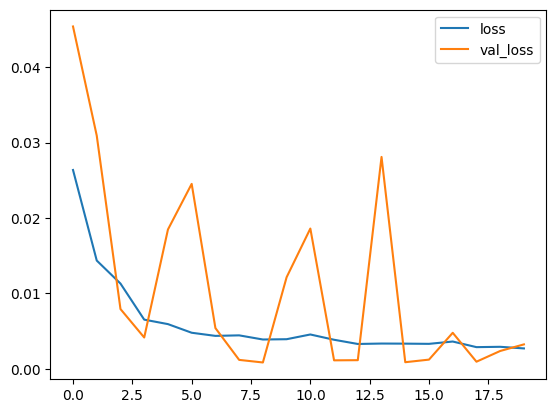

In [34]:
losses.plot()
plt.show()

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

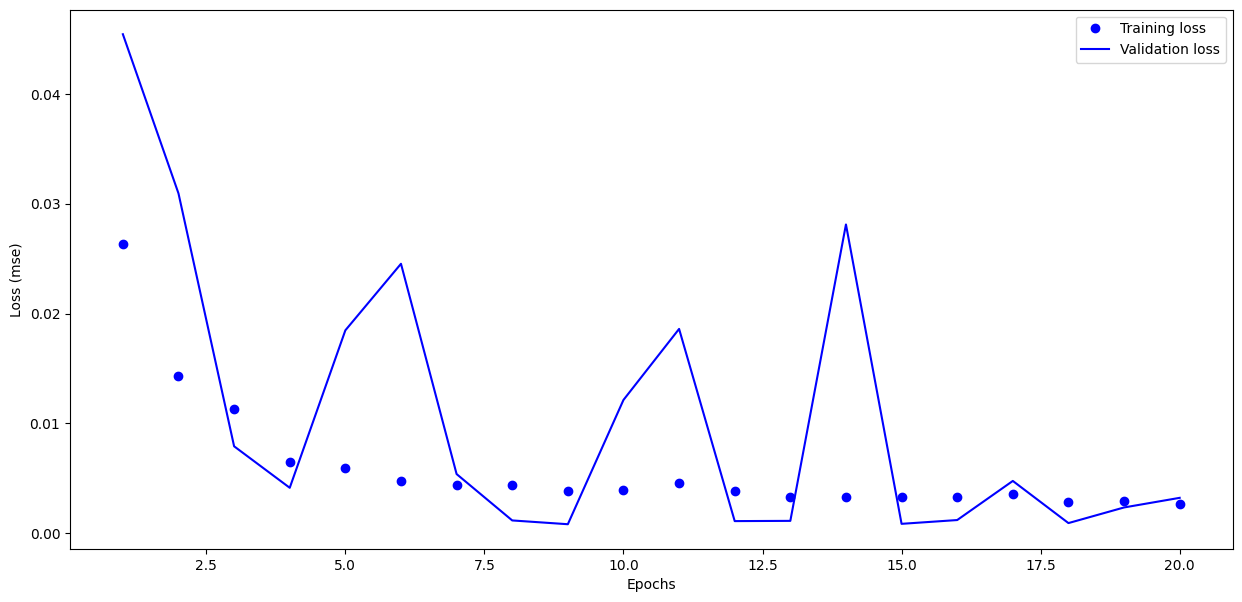

In [35]:
# print Loss for the neural network training process

history_dict = history.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

### Evaluate on Test Data

____________________![image.png](attachment:78ee4976-41bd-457c-8de2-ee2446e02523.png)

In [36]:
print(scaled_train[-15:])

[[0.61523282]
 [0.64077617]
 [0.5909502 ]
 [0.59621235]
 [0.62693562]
 [0.55844547]
 [0.58834653]
 [0.69254803]
 [1.        ]
 [0.44788555]
 [0.49031162]
 [0.59566421]
 [0.58804506]
 [0.63913175]
 [0.59166278]]


____________________![image.png](attachment:7c5efeb5-4631-462d-b593-f7ee0b22b63b.png)

In [37]:
first_eval_batch = scaled_train[-length:]
first_eval_batch

array([[0.59621235],
       [0.62693562],
       [0.55844547],
       [0.58834653],
       [0.69254803],
       [1.        ],
       [0.44788555],
       [0.49031162],
       [0.59566421],
       [0.58804506],
       [0.63913175],
       [0.59166278]])

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [38]:
n_input = 12
first_eval_batch = first_eval_batch.reshape((1, n_input, n_features))
first_eval_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

___________________![image.png](attachment:a2b037af-2ff0-42ce-9234-7ee8a9abb742.png)

In [39]:
model.predict(first_eval_batch.reshape(1, length, n_features))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step


array([[0.65441597]], dtype=float32)

_________________![image.png](attachment:b5adbbdd-43ed-4ee2-9417-382a709986b5.png)

In [40]:
scaled_test[0]

array([0.60665442])

#### Try predicting the series!

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [41]:
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

current_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

____________________![image.png](attachment:2a703099-0587-49e4-9d06-5775208d1bb1.png)

In [42]:
for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]
    test_predictions.append(current_pred)
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


______________________![image.png](attachment:01302ec2-5ad1-4f49-a69b-8692f05a915a.png)

In [43]:
test_predictions

[array([0.65441597], dtype=float32),
 array([0.6862082], dtype=float32),
 array([0.6430525], dtype=float32),
 array([0.660407], dtype=float32),
 array([0.7537857], dtype=float32),
 array([1.0960927], dtype=float32),
 array([0.5438174], dtype=float32),
 array([0.5925401], dtype=float32),
 array([0.667396], dtype=float32),
 array([0.6804372], dtype=float32),
 array([0.7207265], dtype=float32),
 array([0.6941634], dtype=float32),
 array([0.73144674], dtype=float32),
 array([0.7614041], dtype=float32),
 array([0.7335058], dtype=float32),
 array([0.74459666], dtype=float32),
 array([0.83335686], dtype=float32),
 array([1.2096834], dtype=float32)]

### Inverse Transformations and Compare

_________________![image.png](attachment:9266da43-7b93-47a6-b135-724c546cf46b.png)

In [44]:
true_predictions = scaler.inverse_transform(test_predictions)
true_predictions

array([[26653.67531788],
       [27813.67817503],
       [26239.05723768],
       [26872.27045494],
       [30279.37990892],
       [42769.13437986],
       [22618.26550782],
       [24396.01009291],
       [27127.27817923],
       [27603.11237991],
       [29073.14744139],
       [28103.93932098],
       [29464.29731226],
       [30557.35129017],
       [29539.42559427],
       [29944.09833843],
       [33182.6916523 ],
       [46913.71888256]])

_____________![image.png](attachment:1689e362-0bac-4c6c-a993-55ff6789ceb7.png)

In [45]:
test['Predictions'] = true_predictions
test

/tmp/ipykernel_8765/970091196.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


,Sales,Predictions
observation_date,,
2023-07-01,24911,26653.675318
2023-08-01,26657,27813.678175
2023-09-01,23332,26239.057238
2023-10-01,23933,26872.270455
2023-11-01,28580,30279.379909
2023-12-01,40684,42769.134380
2024-01-01,19188,22618.265508
2024-02-01,22005,24396.010093
2024-03-01,24986,27127.278179


### Check and plot predictions

In [ ]:
# Print the test variable

# ...


In [46]:
test

,Sales,Predictions
observation_date,,
2023-07-01,24911,26653.675318
2023-08-01,26657,27813.678175
2023-09-01,23332,26239.057238
2023-10-01,23933,26872.270455
2023-11-01,28580,30279.379909
2023-12-01,40684,42769.134380
2024-01-01,19188,22618.265508
2024-02-01,22005,24396.010093
2024-03-01,24986,27127.278179


_______________![image.png](attachment:f62685ae-fe3d-45e4-b14c-32c3f876ee6c.png)

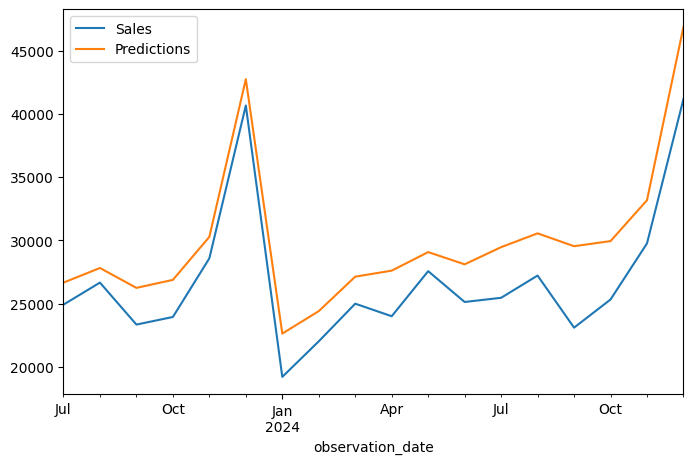

In [47]:
test.plot(figsize=(8,5))
plt.show()

### Retrain and Forecasting

_________________![image.png](attachment:ff8cd5dc-6662-482f-a78b-b18d5cdd5b85.png)

In [48]:
full_scaler = MinMaxScaler()
scaled_full_data = full_scaler.fit_transform(df)

______________![image.png](attachment:e4738fb6-a3cd-4b5f-b347-5042ba0ab433.png)

In [49]:
print(scaled_full_data.max())
print(scaled_full_data.min())

1.0
0.0


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [50]:
length = 12 # Length of the output sequences (in number of timesteps)
generator = TimeseriesGenerator(scaled_full_data,
                                scaled_full_data, length=length, batch_size=1)

In [ ]:
# Use any neural network model based on RNN
# You can also use the model created above
#
# Create the model

# ...
# ...
# ...


In [51]:
full_length = 12

full_generator = TimeseriesGenerator(scaled_full_data, scaled_full_data, length=full_length, batch_size=1)

model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(full_length, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [52]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(optimizer='adam', loss='mse')

In [54]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

# LAST_DIGIT_IN_YOUR_SID =

early_stop = EarlyStopping(monitor='val_loss', patience=11)


____________________![image.png](attachment:7b5b9107-f77e-4327-a987-878819f2ce45.png)

In [55]:
# fit the model

history_2 =  model.fit(generator,  epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stop])

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0202 - val_loss: 0.0312
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0122 - val_loss: 0.0145
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0095 - val_loss: 0.0399
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0059 - val_loss: 0.0060
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0070 - val_loss: 0.0042
Epoch 6/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0050 - val_loss: 0.0114
Epoch 7/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0038 - val_loss: 6.6848e-04
Epoch 8/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0044 - val_loss: 0.0037
Epoch 9/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0034 - val_loss: 0.0024
Epoch 10/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 11/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0037 - val_loss: 8.0194e-04
Epoch 12/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

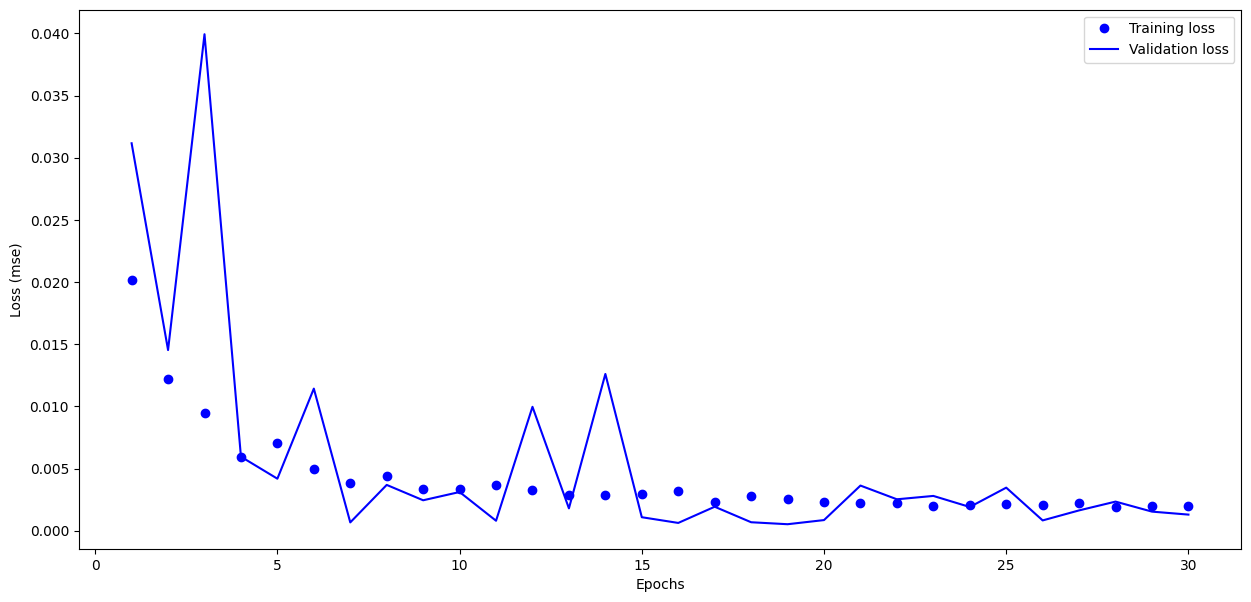

In [56]:
# print Loss for the neural network training process

history_dict = history_2.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

In [ ]:
# You can use the code created above to type the next cell code

_________________![image.png](attachment:02c09230-3aba-4573-8e73-6abd5e03c12a.png)

In [57]:
forecast = []
periods = 12

first_eval_batch = scaled_full_data[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

for i in range(periods):
    current_pred = model.predict(current_batch)[0]
    forecast.append(current_pred)
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 944ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


______________________![image.png](attachment:3072f528-93a6-486e-b230-a376ae174ea2.png)

In [58]:
forecast = scaler.inverse_transform(forecast)
forecast

array([[18823.1357125 ],
       [21381.06178933],
       [24021.60614103],
       [23867.6393773 ],
       [27034.03385758],
       [25579.50508213],
       [25937.8264274 ],
       [27989.69518197],
       [24943.01662409],
       [25932.66781443],
       [30242.90207785],
       [39756.71318769]])

### Creating new timestamp index with pandas.

<html> <h4 style="font-style:italic; color:blue;"> Just run the 4 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [59]:
df

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318


##### Forecast for next 12 months

__________________![image.png](attachment:de68283d-7631-47a5-8071-d3161809ea6c.png)

In [60]:
forecast_index = pd.date_range(start='2025-01-01', periods=periods, freq='MS')

__________________________![image.png](attachment:ee088abb-7456-4031-a648-67d7f8b3cc5e.png)

In [61]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index, columns=['Forecast'])

________________________![image.png](attachment:886da6f6-c14f-41c3-a088-aaaed2bdd344.png)

In [62]:
forecast_df

,Forecast
2025-01-01,18823.135713
2025-02-01,21381.061789
2025-03-01,24021.606141
2025-04-01,23867.639377
2025-05-01,27034.033858
2025-06-01,25579.505082
2025-07-01,25937.826427
2025-08-01,27989.695182
2025-09-01,24943.016624
2025-10-01,25932.667814


__________________![image.png](attachment:a493f4a8-33ea-440d-ad45-8d5a273f8dfb.png)

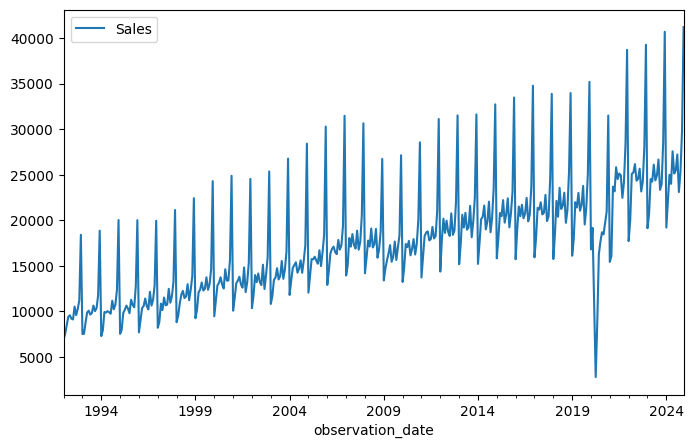

In [63]:
df.plot(figsize=(8,5))
plt.show()

____________________![image.png](attachment:f61a4158-30b1-457d-9aaa-2945b1ec8833.png)

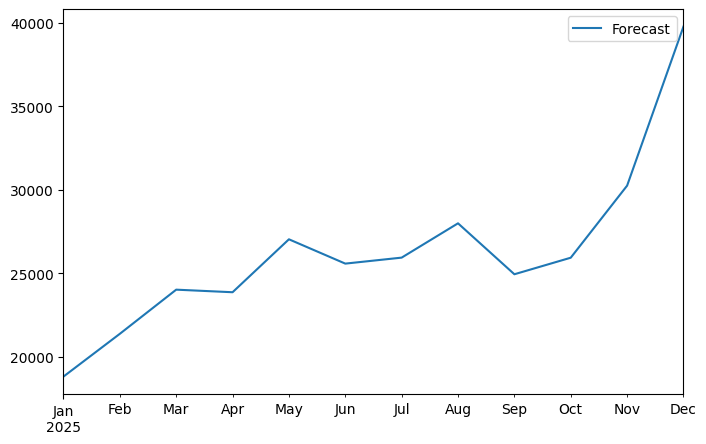

In [64]:
forecast_df.plot(figsize=(8,5))
plt.show()

### Joining pandas plots

https://stackoverflow.com/questions/13872533/plot-different-dataframes-in-the-same-figure

________________________![image.png](attachment:1ad9f420-c284-4442-8931-039f36b4390a.png)

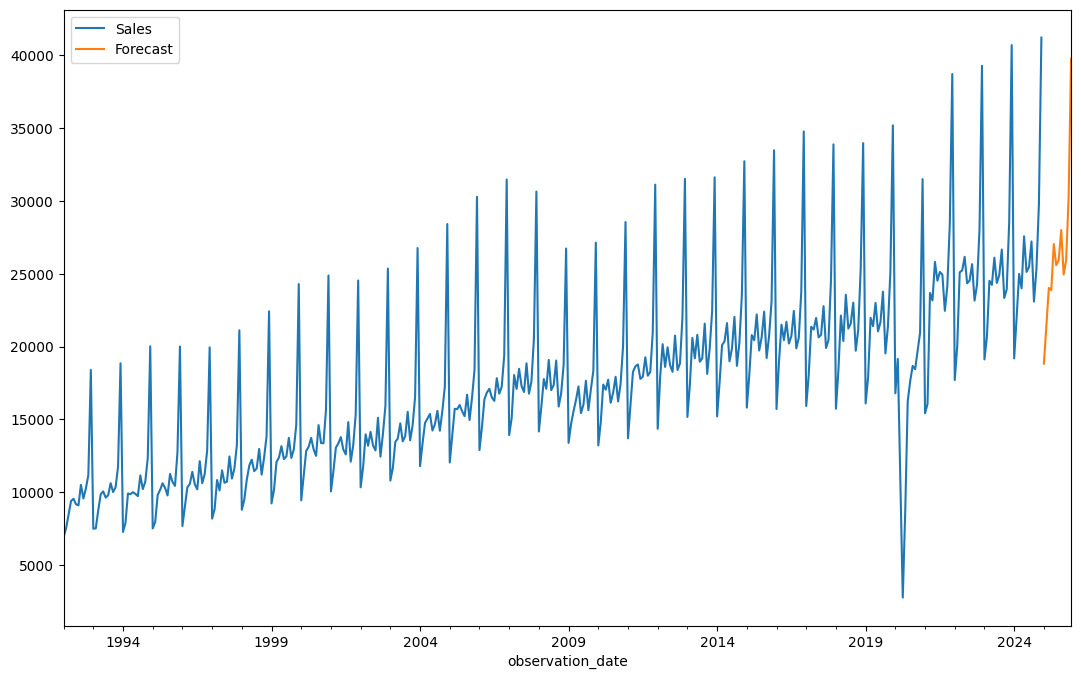

In [65]:
ax = df.plot(figsize=(13,8))
forecast_df.plot(ax=ax)
plt.show()

_______![image.png](attachment:5611350d-0e2b-4867-9b54-de812a2abd8a.png)

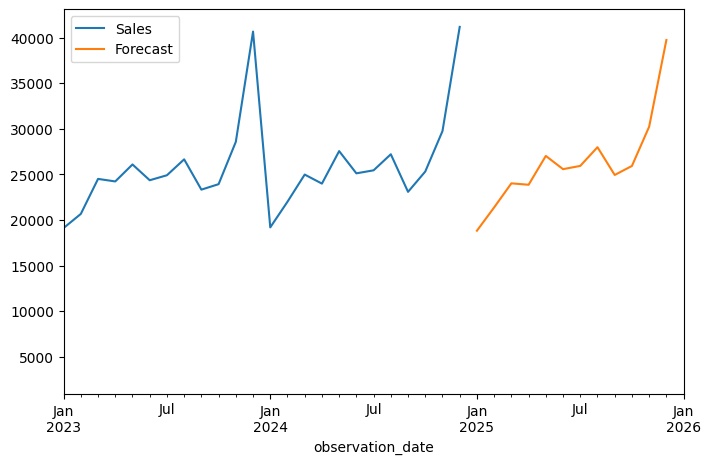

In [66]:
ax = df.plot(figsize=(8,5))
forecast_df.plot(ax=ax)
plt.xlim('2023-01-01','2026-01-01')
plt.show()

### Checking Forecast for last 12 months

_______________________![image.png](attachment:a673cbbb-1303-47a0-98f2-b462c1b68c7a.png)

In [67]:
forecast_index = pd.date_range(start='2024-01-01', periods=periods, freq='MS')
forecast_index

DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

________________________![image.png](attachment:609dc937-f0e4-4c79-afc0-37a15775ca93.png)

In [68]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index, columns=['Forecast'])

___________________![image.png](attachment:ca844afe-754b-40bb-adc1-d40895c0cc67.png)

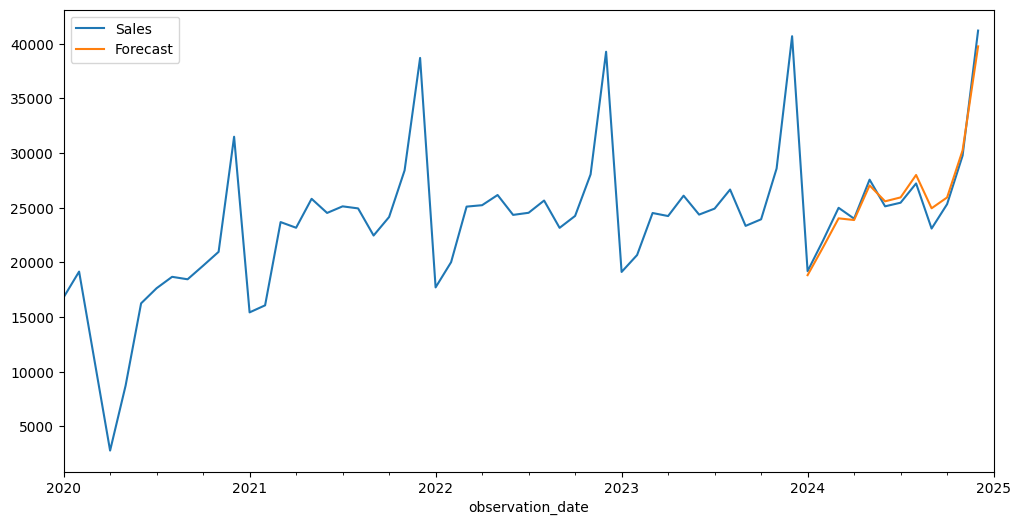

In [69]:
ax = df.plot(figsize=(12,6))
forecast_df.plot(ax=ax)
plt.xlim('2020-01-01','2025-01-01')
plt.show()

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Record the 2nd model's code & plot the summary()

### 2. Copy your early-stop code and history_2 fit-training-process

### 3. Record the plot of validation and test loss of history_2.

### 4. Based on this analysis, determine the optimal number of epochs for training your model.

### 5. Record the plot of the Checking Forecast for the last 12 months (last graph).

In [71]:
# Model creation and summary

model_2 = Sequential()
model_2.add(tf.keras.Input(shape=(length, n_features)))
model_2.add(LSTM(100, activation='relu'))
model_2.add(Dense(1))

model_2.compile(optimizer='adam', loss='mse')

model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
# Early stopping and training

early_stop = EarlyStopping(monitor='val_loss', patience=11)

history_2 = model_2.fit(generator,
                        epochs=30,
                        validation_data=validation_generator,
                        callbacks=[early_stop])

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0186 - val_loss: 0.0274
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0131 - val_loss: 0.0211
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0094 - val_loss: 0.0386
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0055 - val_loss: 0.0485
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0053 - val_loss: 0.0014
Epoch 6/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 7/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0041 - val_loss: 0.0019
Epoch 8/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0039 - val_loss: 0.0012
Epoch 9/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0038 - val_loss: 0.0013
Epoch 10/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0034 - val_loss: 5.1192e-04
Epoch 11/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0031 - val_loss: 5.0338e-04
Epoch 12/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 

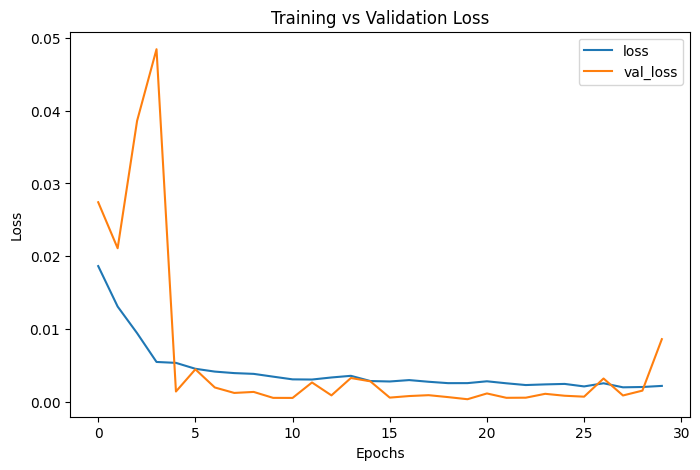

In [73]:
# Plot training and validation loss

losses_2 = pd.DataFrame(history_2.history)

losses_2[['loss','val_loss']].plot(figsize=(8,5))
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.show()

In [74]:
# Find optimal number of epochs

optimal_epoch = losses_2['val_loss'].idxmin() + 1
print("Optimal number of epochs:", optimal_epoch)

Optimal number of epochs: 20


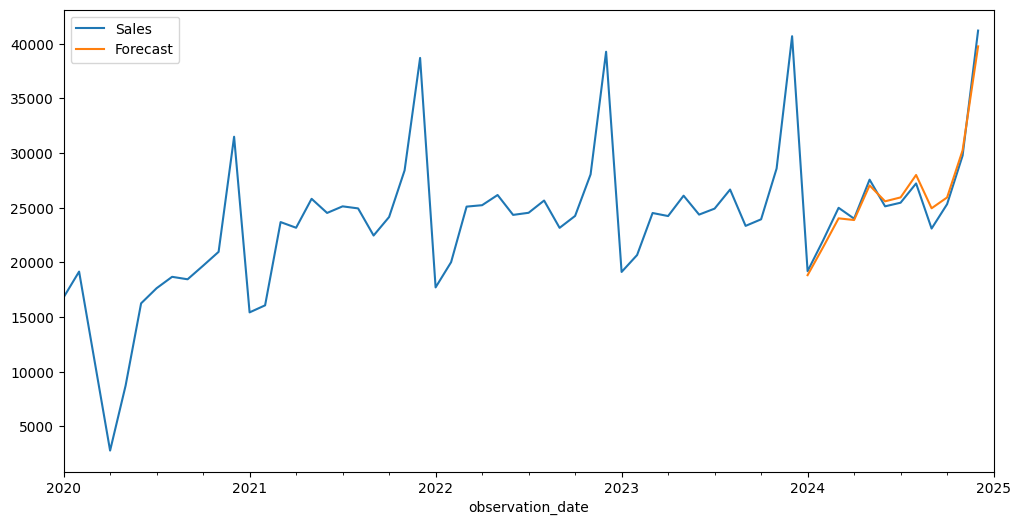

In [75]:
# Plot forecast for last 12 months

forecast_index = pd.date_range(start='2024-01-01', periods=periods, freq='MS')

forecast_df = pd.DataFrame(data=forecast,
                           index=forecast_index,
                           columns=['Forecast'])

ax = df.plot(figsize=(12,6))
forecast_df.plot(ax=ax)

plt.xlim('2020-01-01','2025-01-01')
plt.show()

### Try the same example with a LSTM and/or GRU! (Optional)
Hint: Use LSTM instead of SimpleRNN!

In [77]:
# LSTM model creation and summary

lstm_model = Sequential()
lstm_model.add(tf.keras.Input(shape=(length, n_features)))
lstm_model.add(LSTM(100, activation='relu'))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
# LSTM training

lstm_history = lstm_model.fit(generator,
                              epochs=30,
                              validation_data=validation_generator,
                              callbacks=[early_stop])

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0157 - val_loss: 0.0412
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0130 - val_loss: 0.0222
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0097 - val_loss: 0.0276
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0065 - val_loss: 0.0036
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0046 - val_loss: 0.0149
Epoch 6/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0043 - val_loss: 0.0197
Epoch 7/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0043 - val_loss: 0.0122
Epoch 8/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0036 - val_loss: 5.7402e-04
Epoch 9/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0034 - val_loss: 0.0044
Epoch 10/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 11/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0032 - val_loss: 0.0019


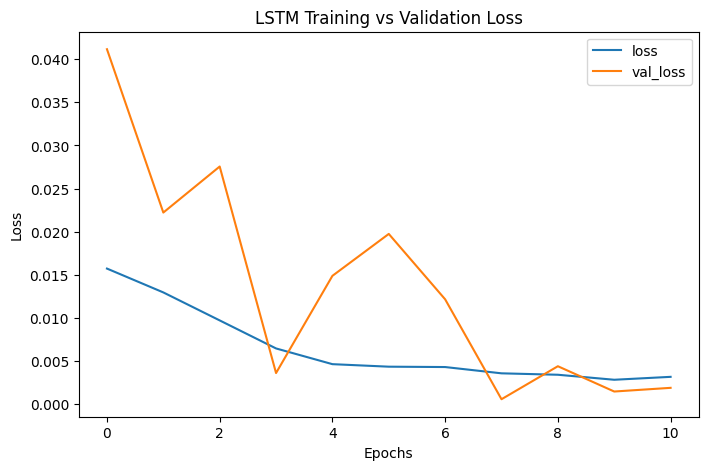

In [79]:
# LSTM loss plot

lstm_losses = pd.DataFrame(lstm_history.history)

lstm_losses[['loss','val_loss']].plot(figsize=(8,5))
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('LSTM Training vs Validation Loss')
plt.show()